In [1]:
import pandas as pd
import numpy as np


In [2]:
df =pd.read_csv('data/Telco_cleaned.csv')

# Descriptive Statistics

### Overview of Dataset

In [14]:
print("=== 1. DATASET SHAPE ===")
print(f"Total Rows (Customers): {df.shape[0]}")
print(f"Total Columns (Features): {df.shape[1]}\n")

=== 1. DATASET SHAPE ===
Total Rows (Customers): 7032
Total Columns (Features): 20



In [15]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  Monthl

The dataset contains 20 columns covering demographic data, subscribed services, account details, and charges.

Demographics: gender, SeniorCitizen, Partner, Dependents

Services: PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies

Account Info: tenure, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges

Target Variable: Churn (Yes/No)


### Analysing the Target Variable (Churn)

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

=== PHASE 2: TARGET VARIABLE ANALYSIS ===
Raw Counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Percentages:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64




C:\Users\User\AppData\Local\Temp\ipykernel_16748\1334354174.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


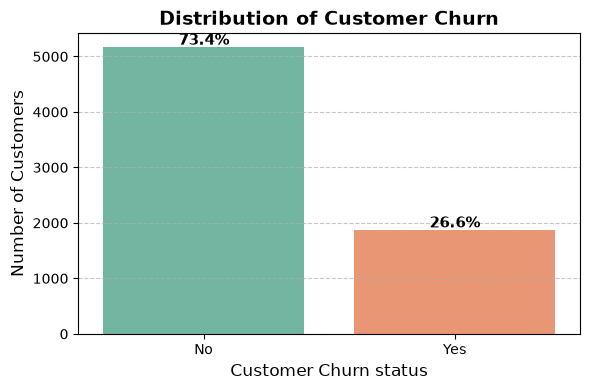

In [18]:
print("=== PHASE 2: TARGET VARIABLE ANALYSIS ===")

# -------------------------------------------------------------
# 1. Calculate Exact Counts and Percentages
# -------------------------------------------------------------
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print("Raw Counts:")
print(churn_counts)
print("\nPercentages:")
print(churn_percentages.round(2))
print("\n" + "="*50 + "\n")

# -------------------------------------------------------------
# 2. Visualize the Distribution (Count Plot)
# -------------------------------------------------------------
plt.figure(figsize=(6, 4))
# Creating a clean bar chart of Churn vs No Churn
sns.countplot(x='Churn', data=df, palette='Set2')

# Styling the plot
plt.title('Distribution of Customer Churn', fontsize=14, fontweight='bold')
plt.xlabel('Customer Churn status', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding the percentage labels on top of the bars
total = len(df)
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 50
    plt.gca().annotate(percentage, (x, y), fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Our data shows us that approximately 73% of the customers stay and 27% churn.

Here is Modeling Note: > Because our data is imbalanced (~73% No / ~27% Yes), Accuracy will be a trap metric. > If a  model guesses "No" for every single customer, it would instantly be 73.5% accurate, but it would catch zero of the customers who are actually leaving—making it totally useless to the business.

Therefore, during modeling, we must focus on:

Recall: To ensure we catch as many of the actual churners as possible (minimizing False Negatives).

F1-Score: To find a healthy balance between Precision and Recall.

Resampling: We might need to look into techniques like SMOTE (oversampling the minority class) or adjusting class weights when training the model.